# Phase 2 — Exploratory Data Analysis

**Goal**: Understand patterns in the cleaned penalty dataset before modeling.

We're answering questions like:
- Where do penalties end up in the goal? How does that vary by taker?
- How do conversion rates vary by zone, pressure, foot, and era?
- Who are the top takers/keepers in our data?
- Are there patterns the model will need to learn?

Each plot has a short note explaining what to look for.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import VerticalPitch

# Display config
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load the cleaned dataset
df = pd.read_csv('../data/processed/penalties_clean.csv')
print(f'Loaded {len(df)} penalties')
print(f'Columns: {len(df.columns)}')
df.head(3)

Loaded 1065 penalties
Columns: 38


,match_id,competition,season,home_team,away_team,home_score,away_score,period,minute,second,is_shootout,taker_id,taker_name,taker_team,keeper_id,keeper_name,keeper_source,shot_outcome,shot_body_part,shot_technique,shot_xg,start_x,start_y,end_x,end_y,end_z,is_goal,year,zone,outcome_category,is_left_foot,is_right_foot,taker_score_at_penalty,opponent_score_at_penalty,score_diff_at_penalty,game_state,shootout_pressure,shootout_kick_num
0,3895302,1. Bundesliga,2023/2024,Bayer Leverkusen,Werder Bremen,5,0,1,24,27,False,32289.0,Victor Okoh Boniface,Bayer Leverkusen,23198,Michael Zetterer,lineup,Goal,Right Foot,Normal,0.7835,108.0,40.0,120.0,42.9,1.0,True,2023,BR,GOAL,False,True,0.0,0.0,0.0,LEVEL,NaN,NaN
1,3895292,1. Bundesliga,2023/2024,Union Berlin,Bayer Leverkusen,0,1,1,52,15,False,40724.0,Florian Wirtz,Bayer Leverkusen,12420,Frederik Rønnow,lineup,Goal,Right Foot,Normal,0.7835,108.0,40.0,120.0,37.5,1.6,True,2023,TL,GOAL,False,True,0.0,0.0,0.0,LEVEL,NaN,NaN
2,3895333,1. Bundesliga,2023/2024,Eintracht Frankfurt,Bayer Leverkusen,1,5,2,57,1,False,28268.0,Exequiel Alejandro Palacios,Bayer Leverkusen,4440,Kevin Trapp,lineup,Goal,Right Foot,Normal,0.7835,108.2,40.1,120.0,43.5,0.2,True,2023,BR,GOAL,False,True,2.0,1.0,1.0,LEADING,NaN,NaN


## 1. Sanity checks

Before plotting, confirm the data is what we think it is.

In [2]:
print('--- Basic stats ---')
print(f'Penalties: {len(df)}')
print(f'Goals: {(df["outcome_category"] == "GOAL").sum()} '
      f'({(df["outcome_category"] == "GOAL").mean():.1%})')
print(f'Unique takers: {df["taker_id"].nunique()}')
print(f'Unique keepers: {df["keeper_id"].nunique()}')
print(f'Unique matches: {df["match_id"].nunique()}')
print(f'Year range: {int(df["year"].min())} - {int(df["year"].max())}')
print(f'\nUNKNOWN game_state rows: {(df["game_state"] == "UNKNOWN").sum()}')
print('(Should be 0)')

--- Basic stats ---
Penalties: 1065
Goals: 795 (74.6%)
Unique takers: 534
Unique keepers: 288
Unique matches: 698
Year range: 1974 - 2024

UNKNOWN game_state rows: 0
(Should be 0)


## 2. Outcome distribution

What happens when a penalty is taken? Six possible outcomes:
- GOAL — ball in the net
- SAVED — keeper made the save
- POST — hit the woodwork, didn't go in
- WIDE — missed wide of the goal
- OVER — missed over the bar
- WAYWARD — extreme misses

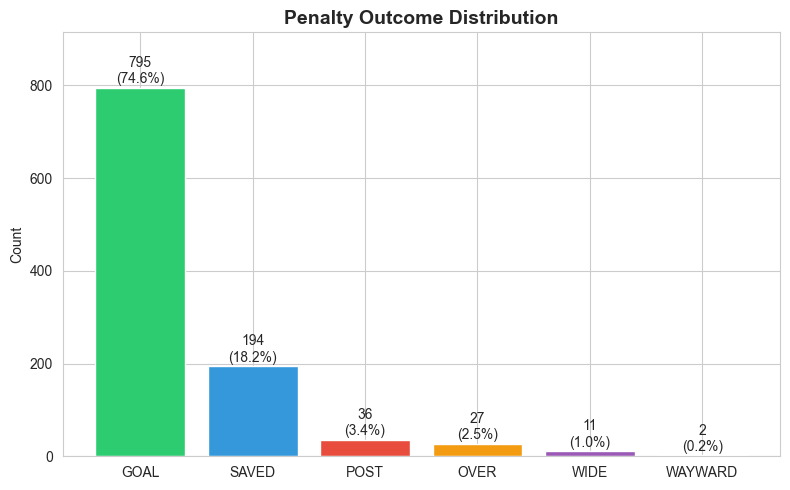

What to look for: ~74-78% goals matches academic baseline.
Saves should be the second-largest category.


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

outcome_counts = df['outcome_category'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']

ax.bar(outcome_counts.index, outcome_counts.values, color=colors[:len(outcome_counts)])

# Annotate each bar with count and percentage
for i, (label, count) in enumerate(outcome_counts.items()):
    pct = count / len(df) * 100
    ax.text(i, count + 10, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

ax.set_title('Penalty Outcome Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, outcome_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print('What to look for: ~74-78% goals matches academic baseline.')
print('Saves should be the second-largest category.')

## 3. Shot end-location heatmap

Where do penalties end up in the goal? Plot all on-target shots overlaid on the goal mouth.

Reminder of coordinates:
- Goal mouth spans y=36 (left post) to y=44 (right post), width 8
- Crossbar at z=2.67 (about 8 feet)
- y=40, z=0 is dead center on the ground

On-target shots: 989


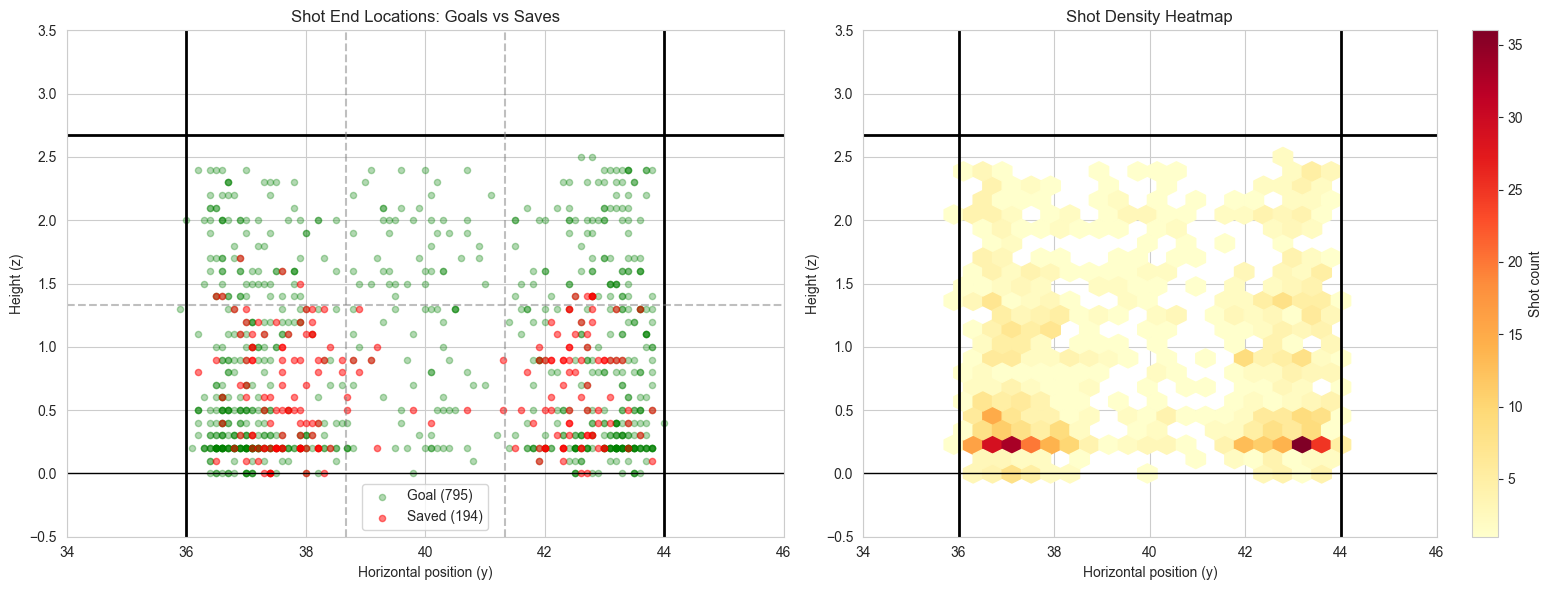

What to look for:
- Most shots are LOW (z < 1.33) — takers play it safe
- Saves cluster around the center; goals cluster at the corners
- Top corners (TL, TR) should have almost no red dots — keepers rarely save them


In [4]:
# Filter to on-target shots (those that ended inside or near the goal)
on_target = df[df['zone'].isin(['TL', 'TC', 'TR', 'BL', 'BC', 'BR'])].copy()
print(f'On-target shots: {len(on_target)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter plot of all shot end locations
ax = axes[0]
goals = on_target[on_target['outcome_category'] == 'GOAL']
saved = on_target[on_target['outcome_category'] == 'SAVED']

ax.scatter(goals['end_y'], goals['end_z'], c='green', alpha=0.3, s=20, label=f'Goal ({len(goals)})')
ax.scatter(saved['end_y'], saved['end_z'], c='red', alpha=0.5, s=20, label=f'Saved ({len(saved)})')

# Draw goal frame
ax.axvline(36, color='black', linewidth=2)
ax.axvline(44, color='black', linewidth=2)
ax.axhline(2.67, color='black', linewidth=2)
ax.axhline(0, color='black', linewidth=1)

# Draw zone boundaries
ax.axvline(38.67, color='gray', linestyle='--', alpha=0.5)
ax.axvline(41.33, color='gray', linestyle='--', alpha=0.5)
ax.axhline(1.33, color='gray', linestyle='--', alpha=0.5)

ax.set_xlim(34, 46)
ax.set_ylim(-0.5, 3.5)
ax.set_xlabel('Horizontal position (y)')
ax.set_ylabel('Height (z)')
ax.set_title('Shot End Locations: Goals vs Saves')
ax.legend()

# Right: 2D heatmap (density)
ax = axes[1]
h = ax.hexbin(on_target['end_y'], on_target['end_z'], gridsize=20, cmap='YlOrRd', mincnt=1)
ax.axvline(36, color='black', linewidth=2)
ax.axvline(44, color='black', linewidth=2)
ax.axhline(2.67, color='black', linewidth=2)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlim(34, 46)
ax.set_ylim(-0.5, 3.5)
ax.set_xlabel('Horizontal position (y)')
ax.set_ylabel('Height (z)')
ax.set_title('Shot Density Heatmap')
plt.colorbar(h, ax=ax, label='Shot count')

plt.tight_layout()
plt.show()

print('What to look for:')
print('- Most shots are LOW (z < 1.33) — takers play it safe')
print('- Saves cluster around the center; goals cluster at the corners')
print('- Top corners (TL, TR) should have almost no red dots — keepers rarely save them')

## 4. Conversion rate by zone

Which zones are most/least dangerous?

      total  goals  conversion
zone                          
TL       93     88    0.946237
TC       46     46    1.000000
TR      101     96    0.950495
BL      367    273    0.743869
BC       65     52    0.800000
BR      317    240    0.757098


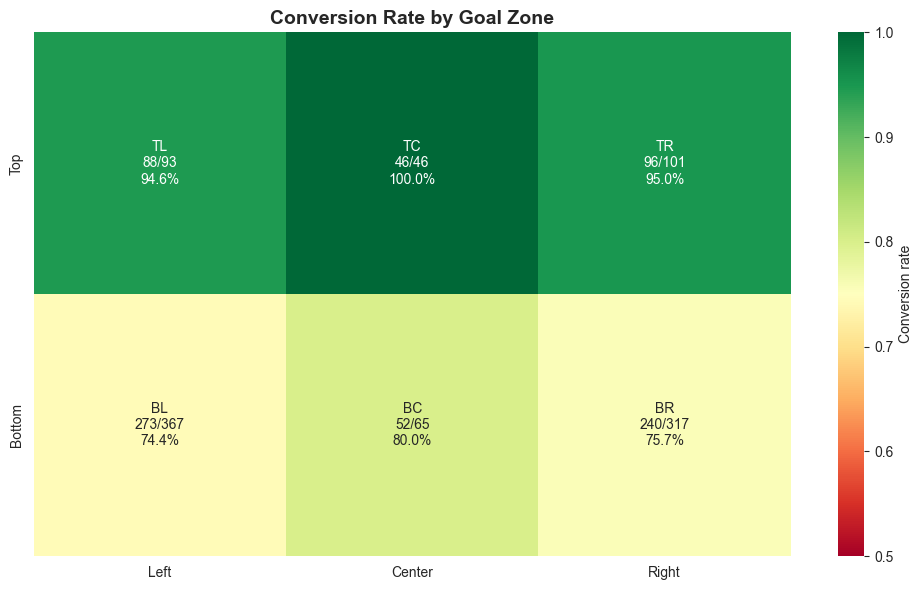


What to look for:
- Top zones (TL, TC, TR) should be deep green (>90% conversion)
- BC (right at the keeper) should be the weakest
- BL/BR are the most-used zones but moderate conversion


In [5]:
# Compute conversion rate per zone (with sample size for confidence)
zone_order = ['TL', 'TC', 'TR', 'BL', 'BC', 'BR']

zone_stats = on_target.groupby('zone').agg(
    total=('outcome_category', 'count'),
    goals=('outcome_category', lambda x: (x == 'GOAL').sum())
)
zone_stats['conversion'] = zone_stats['goals'] / zone_stats['total']
zone_stats = zone_stats.reindex(zone_order)

# Print the table
print(zone_stats.to_string())

# Plot as a 3x2 grid that matches the goal layout
fig, ax = plt.subplots(figsize=(10, 6))

# Create a 2-row, 3-col grid that visually matches goal positions
grid = np.array([
    [zone_stats.loc['TL', 'conversion'], zone_stats.loc['TC', 'conversion'], zone_stats.loc['TR', 'conversion']],
    [zone_stats.loc['BL', 'conversion'], zone_stats.loc['BC', 'conversion'], zone_stats.loc['BR', 'conversion']],
])

labels = np.array([
    [f"TL\n{zone_stats.loc['TL', 'goals']}/{zone_stats.loc['TL', 'total']}\n{zone_stats.loc['TL', 'conversion']:.1%}",
     f"TC\n{zone_stats.loc['TC', 'goals']}/{zone_stats.loc['TC', 'total']}\n{zone_stats.loc['TC', 'conversion']:.1%}",
     f"TR\n{zone_stats.loc['TR', 'goals']}/{zone_stats.loc['TR', 'total']}\n{zone_stats.loc['TR', 'conversion']:.1%}"],
    [f"BL\n{zone_stats.loc['BL', 'goals']}/{zone_stats.loc['BL', 'total']}\n{zone_stats.loc['BL', 'conversion']:.1%}",
     f"BC\n{zone_stats.loc['BC', 'goals']}/{zone_stats.loc['BC', 'total']}\n{zone_stats.loc['BC', 'conversion']:.1%}",
     f"BR\n{zone_stats.loc['BR', 'goals']}/{zone_stats.loc['BR', 'total']}\n{zone_stats.loc['BR', 'conversion']:.1%}"],
])

sns.heatmap(grid, annot=labels, fmt='', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            cbar_kws={'label': 'Conversion rate'}, ax=ax,
            xticklabels=['Left', 'Center', 'Right'],
            yticklabels=['Top', 'Bottom'])
ax.set_title('Conversion Rate by Goal Zone', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nWhat to look for:')
print('- Top zones (TL, TC, TR) should be deep green (>90% conversion)')
print('- BC (right at the keeper) should be the weakest')
print('- BL/BR are the most-used zones but moderate conversion')

## 5. Shot placement frequency vs conversion

Are takers picking the zones that maximize their chances? Or are they playing it safe?

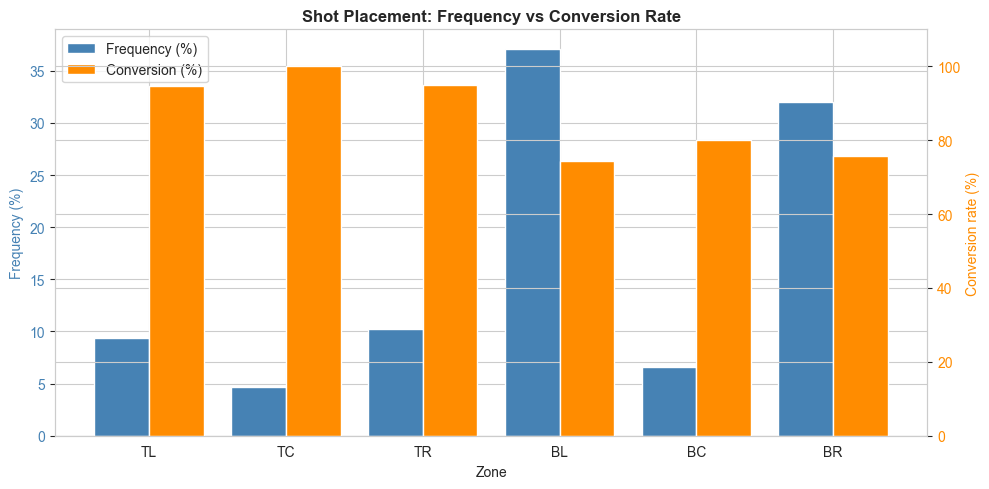

What this reveals:
- BL and BR are picked most often but convert at ~75%
- TL, TC, TR are picked rarely but convert at 90%+
- The data shows a clear risk-aversion bias among takers


In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(zone_order))
width = 0.4

# Bar 1: Frequency (how often shots go to each zone)
freq = zone_stats['total'] / zone_stats['total'].sum()
bars1 = ax1.bar(x - width/2, freq * 100, width, label='Frequency (%)', color='steelblue')
ax1.set_ylabel('Frequency (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(zone_order)

# Bar 2: Conversion rate (on a second axis)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, zone_stats['conversion'] * 100, width, label='Conversion (%)', color='darkorange')
ax2.set_ylabel('Conversion rate (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 110)

ax1.set_title('Shot Placement: Frequency vs Conversion Rate', fontweight='bold')
ax1.set_xlabel('Zone')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print('What this reveals:')
print('- BL and BR are picked most often but convert at ~75%')
print('- TL, TC, TR are picked rarely but convert at 90%+')
print('- The data shows a clear risk-aversion bias among takers')

## 6. Game state effect (in-game penalties)

Does the score affect conversion?

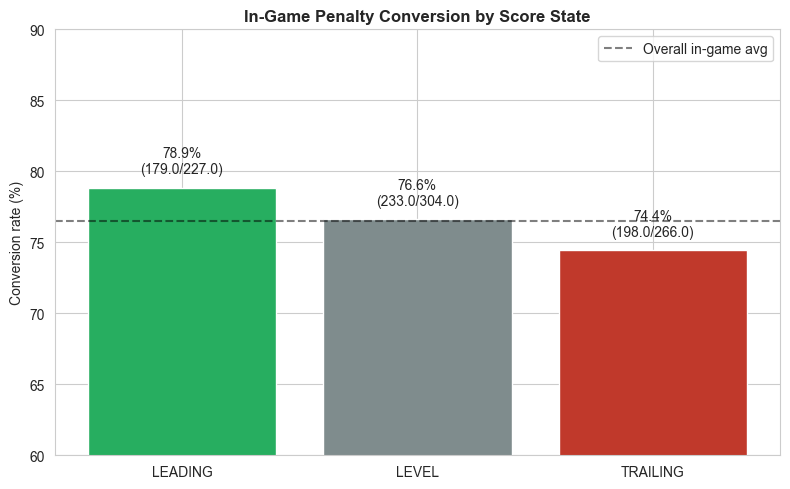

            total  goals  conversion
game_state                          
LEADING       227    179    0.788546
LEVEL         304    233    0.766447
TRAILING      266    198    0.744361

What to look for:
- Clear gradient: LEADING > LEVEL > TRAILING
- ~5pp drop from leading to trailing — meaningful pressure effect


In [7]:
in_game = df[~df['is_shootout']].copy()

state_order = ['LEADING', 'LEVEL', 'TRAILING']
state_stats = in_game.groupby('game_state').agg(
    total=('outcome_category', 'count'),
    goals=('outcome_category', lambda x: (x == 'GOAL').sum())
)
state_stats['conversion'] = state_stats['goals'] / state_stats['total']
state_stats = state_stats.reindex(state_order)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#27ae60', '#7f8c8d', '#c0392b']
bars = ax.bar(state_order, state_stats['conversion'] * 100, color=colors)

for i, (state, row) in enumerate(state_stats.iterrows()):
    ax.text(i, row['conversion'] * 100 + 1,
            f"{row['conversion']:.1%}\n({row['goals']}/{row['total']})",
            ha='center', fontsize=10)

ax.set_ylim(60, 90)
ax.set_ylabel('Conversion rate (%)')
ax.set_title('In-Game Penalty Conversion by Score State', fontweight='bold')
ax.axhline(in_game['outcome_category'].eq('GOAL').mean() * 100, 
           color='black', linestyle='--', alpha=0.5, label='Overall in-game avg')
ax.legend()
plt.tight_layout()
plt.show()

print(state_stats)
print('\nWhat to look for:')
print('- Clear gradient: LEADING > LEVEL > TRAILING')
print('- ~5pp drop from leading to trailing — meaningful pressure effect')

## 7. Shootout pressure effect

This is where pressure shows the strongest signal.

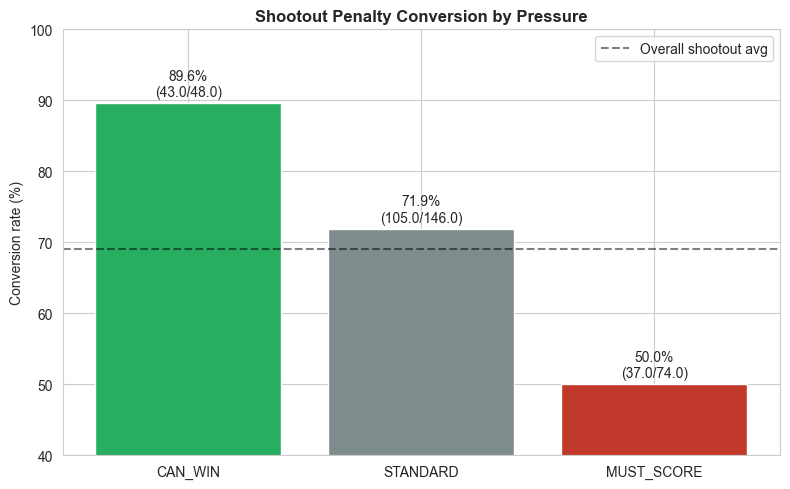

                   total  goals  conversion
shootout_pressure                          
CAN_WIN               48     43    0.895833
STANDARD             146    105    0.719178
MUST_SCORE            74     37    0.500000

What to look for:
- MUST_SCORE drops near 50% — half of "must-score" penalties fail
- ~40pp gap between CAN_WIN and MUST_SCORE
- This is THE signature finding of penalty research


In [8]:
shootouts = df[df['is_shootout']].copy()

pressure_order = ['CAN_WIN', 'STANDARD', 'MUST_SCORE']
pressure_stats = shootouts.groupby('shootout_pressure').agg(
    total=('outcome_category', 'count'),
    goals=('outcome_category', lambda x: (x == 'GOAL').sum())
)
pressure_stats['conversion'] = pressure_stats['goals'] / pressure_stats['total']
pressure_stats = pressure_stats.reindex(pressure_order)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#27ae60', '#7f8c8d', '#c0392b']
ax.bar(pressure_order, pressure_stats['conversion'] * 100, color=colors)

for i, (state, row) in enumerate(pressure_stats.iterrows()):
    ax.text(i, row['conversion'] * 100 + 1,
            f"{row['conversion']:.1%}\n({row['goals']}/{row['total']})",
            ha='center', fontsize=10)

ax.set_ylim(40, 100)
ax.set_ylabel('Conversion rate (%)')
ax.set_title('Shootout Penalty Conversion by Pressure', fontweight='bold')
ax.axhline(shootouts['outcome_category'].eq('GOAL').mean() * 100,
           color='black', linestyle='--', alpha=0.5, label='Overall shootout avg')
ax.legend()
plt.tight_layout()
plt.show()

print(pressure_stats)
print('\nWhat to look for:')
print('- MUST_SCORE drops near 50% — half of "must-score" penalties fail')
print('- ~40pp gap between CAN_WIN and MUST_SCORE')
print('- This is THE signature finding of penalty research')

## 8. Foot preference effect

Do left-footed and right-footed takers aim differently?

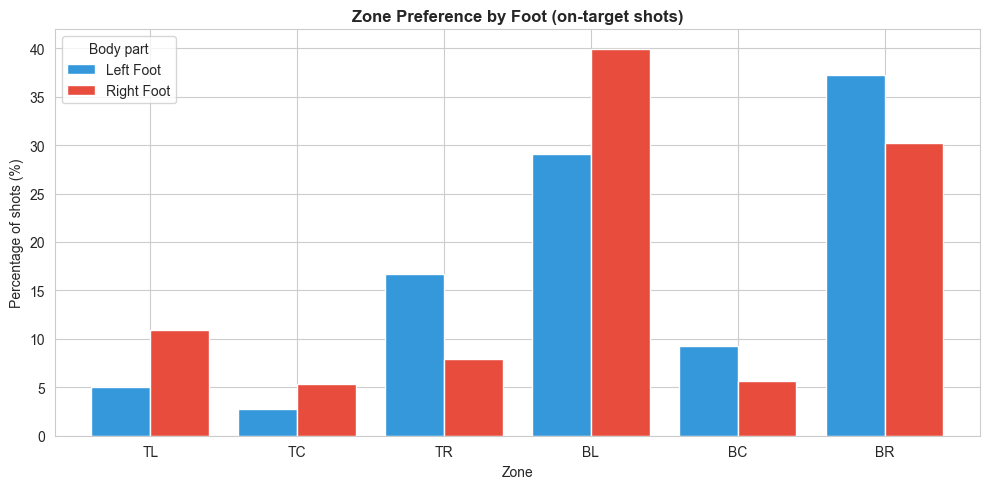

zone              TL   TC    TR    BL   BC    BR
shot_body_part                                  
Left Foot        5.0  2.7  16.7  29.1  9.3  37.2
Right Foot      10.9  5.3   7.9  39.9  5.6  30.2

What to look for:
- Right-footers typically favor their natural side (the keeper's left = BL/TL)
- Left-footers should mirror: favor BR/TR
- If patterns are weak, foot may matter less than we think


In [9]:
# Zone distribution for each foot
foot_zone = on_target.groupby(['shot_body_part', 'zone']).size().unstack(fill_value=0)
foot_zone = foot_zone[zone_order]  # consistent column order
foot_zone_pct = foot_zone.div(foot_zone.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
foot_zone_pct.T.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], width=0.8)
ax.set_title('Zone Preference by Foot (on-target shots)', fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Percentage of shots (%)')
ax.legend(title='Body part')
ax.set_xticklabels(zone_order, rotation=0)
plt.tight_layout()
plt.show()

print(foot_zone_pct.round(1))
print('\nWhat to look for:')
print('- Right-footers typically favor their natural side (the keeper\'s left = BL/TL)')
print('- Left-footers should mirror: favor BR/TR')
print('- If patterns are weak, foot may matter less than we think')

## 9. Top takers by sample size

Who has the most penalties in our data? Their conversion rates with sample size.

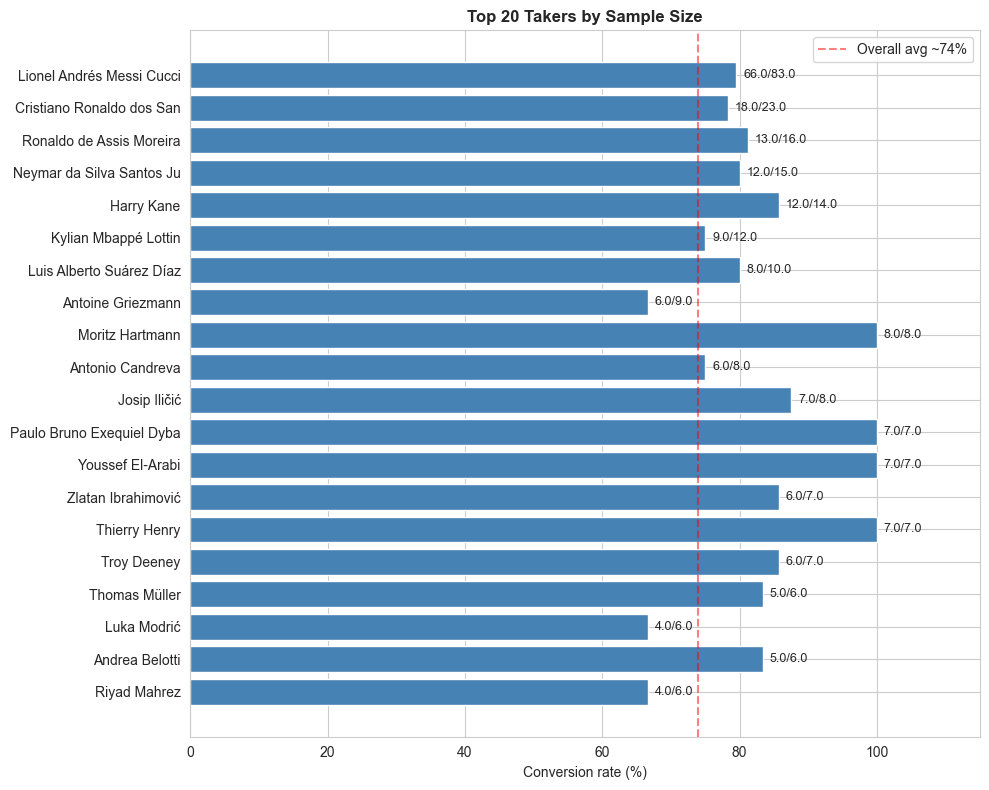

Note: Small sample sizes mean conversion rates here are unreliable.
A taker with 5/5 isn't actually "100%" — we'll handle this with
Bayesian smoothing when we build player profiles.


In [10]:
taker_stats = df.groupby('taker_name').agg(
    total=('outcome_category', 'count'),
    goals=('outcome_category', lambda x: (x == 'GOAL').sum())
).sort_values('total', ascending=False)
taker_stats['conversion'] = taker_stats['goals'] / taker_stats['total']

top20 = taker_stats.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top20))
bars = ax.barh(y_pos, top20['conversion'] * 100, color='steelblue')

for i, (name, row) in enumerate(top20.iterrows()):
    ax.text(row['conversion'] * 100 + 1, i,
            f"{row['goals']}/{row['total']}",
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([n[:25] for n in top20.index])  # truncate long names
ax.invert_yaxis()
ax.set_xlabel('Conversion rate (%)')
ax.set_xlim(0, 115)
ax.axvline(74, color='red', linestyle='--', alpha=0.5, label='Overall avg ~74%')
ax.set_title('Top 20 Takers by Sample Size', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Note: Small sample sizes mean conversion rates here are unreliable.')
print('A taker with 5/5 isn\'t actually "100%" — we\'ll handle this with')
print('Bayesian smoothing when we build player profiles.')

## 10. Top keepers by penalties faced

Who's faced the most? What's their save rate?

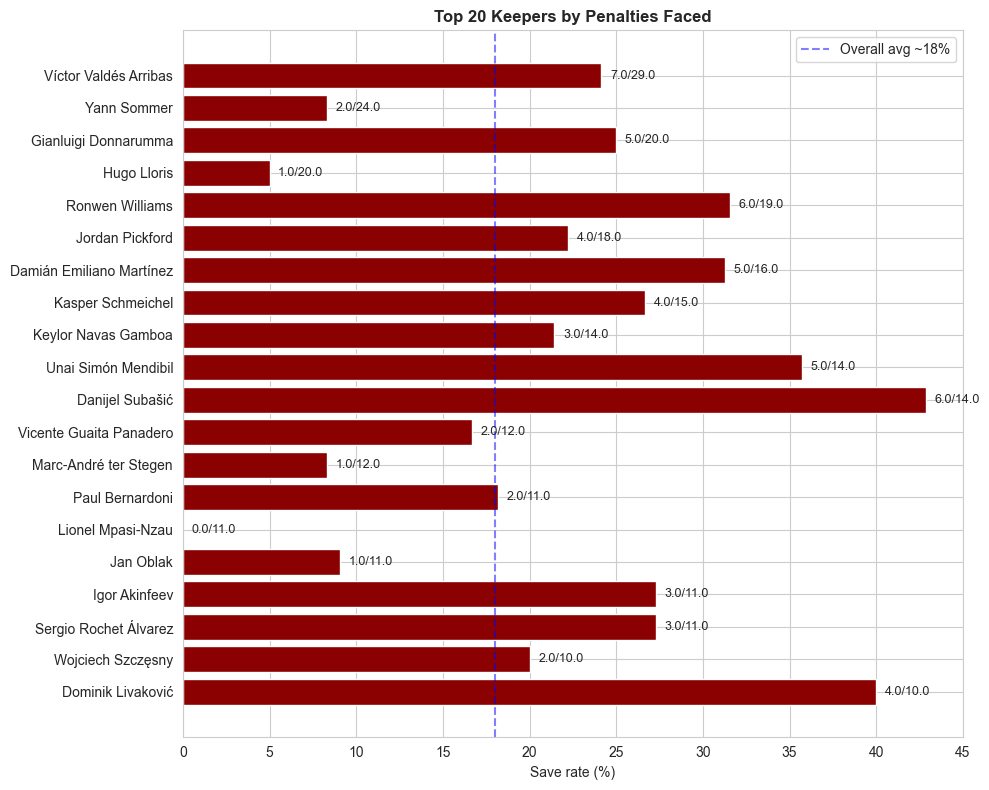

In [11]:
keeper_stats = df.groupby('keeper_name').agg(
    total=('outcome_category', 'count'),
    saved=('outcome_category', lambda x: (x == 'SAVED').sum()),
    goals_conceded=('outcome_category', lambda x: (x == 'GOAL').sum())
).sort_values('total', ascending=False)
keeper_stats['save_rate'] = keeper_stats['saved'] / keeper_stats['total']
keeper_stats['concession_rate'] = keeper_stats['goals_conceded'] / keeper_stats['total']

top20_kp = keeper_stats.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top20_kp))
ax.barh(y_pos, top20_kp['save_rate'] * 100, color='darkred')

for i, (name, row) in enumerate(top20_kp.iterrows()):
    ax.text(row['save_rate'] * 100 + 0.5, i,
            f"{row['saved']}/{row['total']}",
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([n[:25] for n in top20_kp.index])
ax.invert_yaxis()
ax.set_xlabel('Save rate (%)')
ax.axvline(18, color='blue', linestyle='--', alpha=0.5, label='Overall avg ~18%')
ax.set_title('Top 20 Keepers by Penalties Faced', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Conversion rate over time

Has penalty conversion changed over the decades?

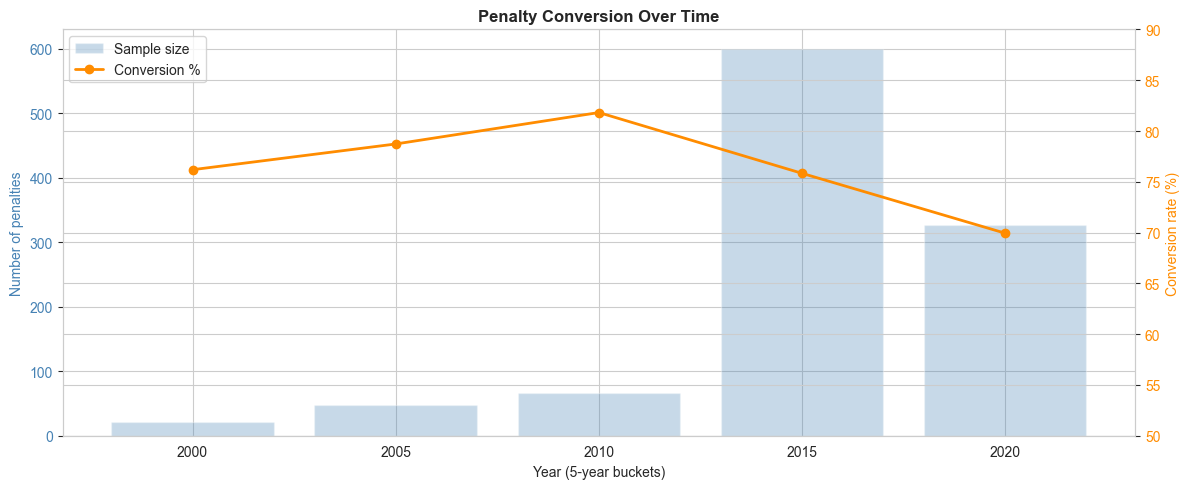

             total  goals  conversion
year_bucket                          
2000            21     16    0.761905
2005            47     37    0.787234
2010            66     54    0.818182
2015           600    455    0.758333
2020           326    228    0.699387

What to look for:
- Conversion rate should be roughly stable around 70-80%
- Sample size grows dramatically in recent years (StatsBomb coverage)


In [12]:
# Group by 5-year buckets for cleaner trends
df['year_bucket'] = (df['year'] // 5 * 5).astype(int)

year_stats = df.groupby('year_bucket').agg(
    total=('outcome_category', 'count'),
    goals=('outcome_category', lambda x: (x == 'GOAL').sum())
)
year_stats['conversion'] = year_stats['goals'] / year_stats['total']

# Filter to buckets with at least 20 penalties for stability
year_stats = year_stats[year_stats['total'] >= 20]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(year_stats.index, year_stats['total'], width=4, alpha=0.3, color='steelblue', label='Sample size')
ax1.set_ylabel('Number of penalties', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(year_stats.index, year_stats['conversion'] * 100, marker='o', color='darkorange', linewidth=2, label='Conversion %')
ax2.set_ylabel('Conversion rate (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(50, 90)

ax1.set_xlabel('Year (5-year buckets)')
ax1.set_title('Penalty Conversion Over Time', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(year_stats)
print('\nWhat to look for:')
print('- Conversion rate should be roughly stable around 70-80%')
print('- Sample size grows dramatically in recent years (StatsBomb coverage)')

## 12. Distribution of penalties per taker

How much data do we have per player? This is critical — most takers will only have 1-2 penalties, which means we can't trust their individual conversion rates without Bayesian smoothing.

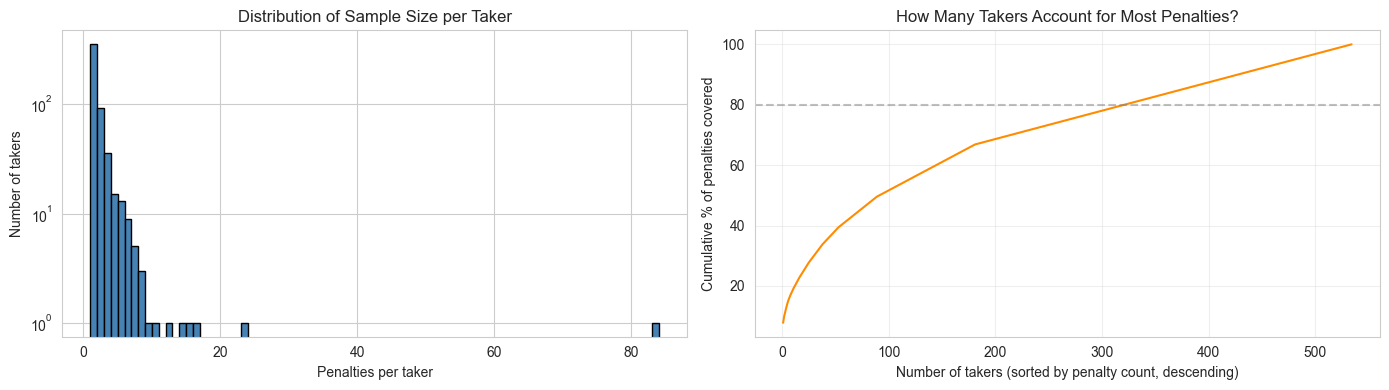

Total unique takers: 534
Takers with only 1 penalty:  353 (66.1%)
Takers with 5+ penalties:    38
Takers with 10+ penalties:   7
Takers with 20+ penalties:   2

This is exactly why we need Bayesian smoothing for player profiles.


In [13]:
taker_counts = df.groupby('taker_name').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(taker_counts, bins=range(1, taker_counts.max() + 2), color='steelblue', edgecolor='black')
axes[0].set_xlabel('Penalties per taker')
axes[0].set_ylabel('Number of takers')
axes[0].set_title('Distribution of Sample Size per Taker')
axes[0].set_yscale('log')

# Cumulative coverage
sorted_counts = taker_counts.sort_values(ascending=False).values
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
axes[1].plot(range(1, len(sorted_counts) + 1), cumulative, color='darkorange')
axes[1].set_xlabel('Number of takers (sorted by penalty count, descending)')
axes[1].set_ylabel('Cumulative % of penalties covered')
axes[1].set_title('How Many Takers Account for Most Penalties?')
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total unique takers: {len(taker_counts)}')
print(f'Takers with only 1 penalty:  {(taker_counts == 1).sum()} ({(taker_counts == 1).mean():.1%})')
print(f'Takers with 5+ penalties:    {(taker_counts >= 5).sum()}')
print(f'Takers with 10+ penalties:   {(taker_counts >= 10).sum()}')
print(f'Takers with 20+ penalties:   {(taker_counts >= 20).sum()}')
print('\nThis is exactly why we need Bayesian smoothing for player profiles.')

## 13. In-game vs shootout: zone preference

Do takers shoot differently when the stakes are different?

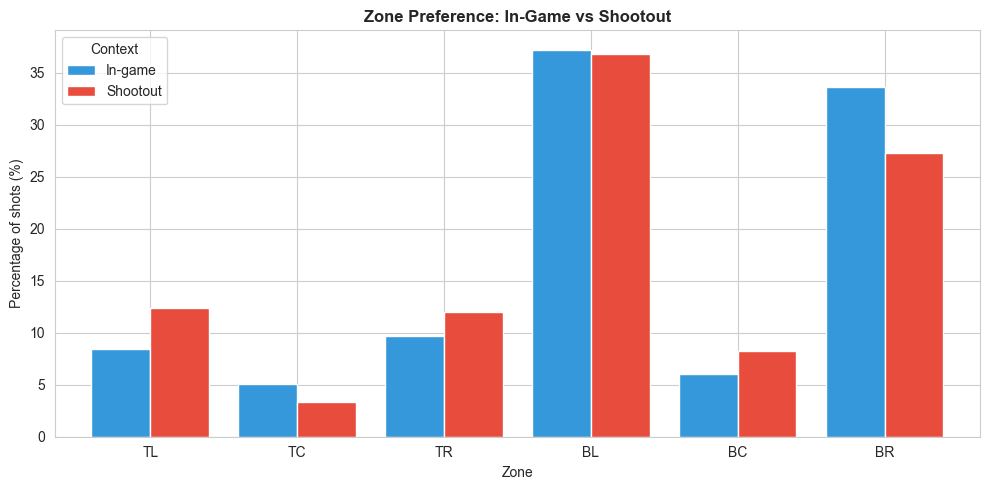

zone        TL   TC    TR    BL   BC    BR
In-game    8.4  5.1   9.6  37.2  6.0  33.6
Shootout  12.4  3.3  12.0  36.8  8.3  27.3

What to look for:
- Are top zones used more often in shootouts? (Higher stakes -> more conservative? or riskier?)
- Are takers more central in shootouts? (Aim away from corners under pressure?)


In [14]:
context_zone = on_target.groupby(['is_shootout', 'zone']).size().unstack(fill_value=0)
context_zone = context_zone[zone_order]
context_zone_pct = context_zone.div(context_zone.sum(axis=1), axis=0) * 100
context_zone_pct.index = ['In-game', 'Shootout']

fig, ax = plt.subplots(figsize=(10, 5))
context_zone_pct.T.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], width=0.8)
ax.set_title('Zone Preference: In-Game vs Shootout', fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Percentage of shots (%)')
ax.legend(title='Context')
ax.set_xticklabels(zone_order, rotation=0)
plt.tight_layout()
plt.show()

print(context_zone_pct.round(1))
print('\nWhat to look for:')
print('- Are top zones used more often in shootouts? (Higher stakes -> more conservative? or riskier?)')
print('- Are takers more central in shootouts? (Aim away from corners under pressure?)')

## Summary

Key findings from EDA:

1. **74-78% baseline conversion** — matches academic research
2. **Top corners are nearly unsavable** but rarely used — clear risk/reward tradeoff
3. **Bottom corners dominate placement** — the conservative choice
4. **Pressure effect is real**:
   - In-game: ~5pp drop from LEADING to TRAILING
   - Shootout: ~40pp drop from CAN_WIN to MUST_SCORE
5. **Most takers have only 1-2 penalties** — Bayesian smoothing is essential for profiles
6. **Conversion rates have been stable** for decades — penalty mechanics don't change

These insights directly inform Phase 2 Step 3 (player profiles) and Phase 3 (modeling).

Specifically, our model needs to learn:
- Per-zone outcome probabilities (already very different)
- Per-taker zone preference distributions
- Per-keeper save rates by zone
- Context-dependent adjustments (pressure, score state)
- How to handle small-sample players (Bayesian priors)